### 1) Import Libraries

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import to_rgba
from matplotlib.colors import TwoSlopeNorm
from matplotlib import rc
import matplotlib.cm as cm
import xarray as xr
import numpy as np
from pathlib import Path
from matplotlib import cm, colors
import os
import pyproj
from pyproj import datadir
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec


rc('mathtext', default='regular')

os.environ["PROJ_LIB"] = "/opt/homebrew/opt/proj/share/proj"
datadir.set_data_dir("/opt/homebrew/opt/proj/share/proj")
# print(pyproj.datadir.get_data_dir())


### 2) Load Data & Results

In [ ]:
# === Define paths ===
path_q_gis_in = '../data/camels/CAMELScl_boundaries_epsg4326.gpkg'
path_gw_results = '../analysis/4_GW_Q_memory/csv/gw_memory.csv'
path_q_results = '../analysis/4_GW_Q_memory/csv/q_memory.csv'
path_netcdf = '../data/other/elevation_srtm_v4.1_Chile_2000_1200m_epsg4326.nc'


# === Load the CSV files ===
gw_data = pd.read_csv(path_gw_results)
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv').rename(columns={'cr2sub_id': 'well_id'})
q_data = pd.read_csv(path_q_results)
q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
q_attrib['p_mean_cr2met_1979_2010'] = 365*q_attrib['p_mean_cr2met_1979_2010'] 

# === Load the GeoPackage files ===
gwl_gpkg = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
q_gpkg = gpd.read_file(path_q_gis_in)

# === Normalize identifier columns so merges succeed ===
def normalize_numeric_id(series):
    numeric = pd.to_numeric(series, errors='coerce')
    return numeric.astype('Int64')

for frame, column in [(gwl_gpkg, 'cr2sub_id'), (gw_data, 'cr2sub_id'), (q_gpkg, 'gauge_id'), (q_data, 'gauge_id')]:
    frame[column] = normalize_numeric_id(frame[column])
    frame.dropna(subset=[column], inplace=True)
    frame[column] = frame[column].astype(str)

# === Load the NetCDF file ===
ds = xr.open_dataset(path_netcdf)
# print(ds)

# Clip DEM during load to avoid handling the full global raster
dem_min_lon, dem_max_lon = -74, -69
dem_min_lat, dem_max_lat = -41.8, -26.5

def slice_dim(dataarray, dim_name, lower, upper):
    coord = dataarray.coords[dim_name]
    start, end = (lower, upper) if coord[0] <= coord[-1] else (upper, lower)
    return dataarray.sel({dim_name: slice(start, end)})

elevation = ds['elevation_srtm_v4.1_Chile_2000_1200m_epsg4326']
elevation = slice_dim(elevation, 'longitude', dem_min_lon, dem_max_lon)
elevation = slice_dim(elevation, 'latitude', dem_min_lat, dem_max_lat)

# === Load the region shapefile ===
path_shp = '../data/other/cl_regiones_geo/cl_regiones_geo.shp'
regions_gdf = gpd.read_file(path_shp)

# === Merge CSV with GeoPackage ===
gwl_merged = gwl_gpkg.merge(gw_data, left_on='cr2sub_id', right_on='cr2sub_id', how='left')
q_merged = q_gpkg.merge(q_data, left_on='gauge_id', right_on='gauge_id', how='left')

# === Save the new GeoPackages ===
gwl_gpkg = gwl_merged
q_gpkg = q_merged

# === Fixing Multi-part geometries ===
if q_gpkg.geom_type.isin(['MultiPolygon', 'MultiLineString']).any():
    q_gpkg = q_gpkg.explode(index_parts=False)

if gwl_gpkg.geom_type.isin(['MultiPolygon', 'MultiLineString']).any():
    gwl_gpkg = gwl_gpkg.explode(index_parts=False)

# === Remove any invalid geometries ===
q_gpkg = q_gpkg[q_gpkg.is_valid]
gwl_gpkg = gwl_gpkg[gwl_gpkg.is_valid]


# === Optional: load global ETOPO DEM for comparison ===
etopo_path = '../data/other/ETOPO_2022_v1_30s_N90W180_bed.nc'
etopo_ds = xr.open_dataset(etopo_path)
elevation_etopo = etopo_ds['z']
elevation_etopo = slice_dim(elevation_etopo, 'lon', dem_min_lon, dem_max_lon)
elevation_etopo = slice_dim(elevation_etopo, 'lat', dem_min_lat, dem_max_lat)



### Fig. Hydrological memory - 2-side maps

/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_20541/1210792860.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_list = cm.get_cmap('inferno')(np.linspace(1, 0, len(bins) - 1))
/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_20541/1210792860.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


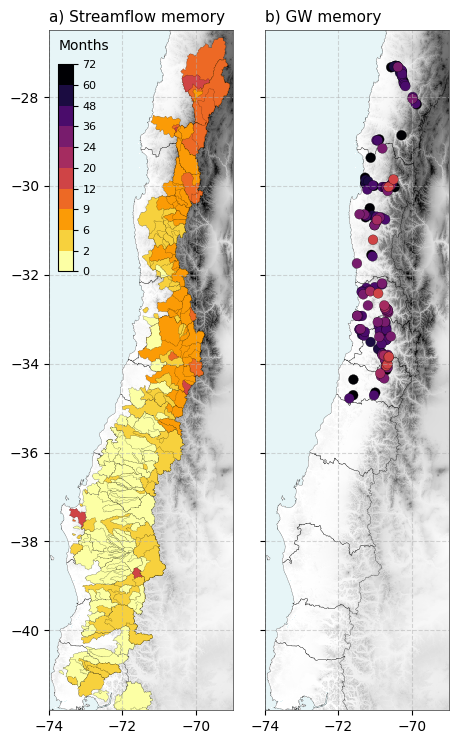

In [14]:
######### MAP HYDROLOGICAL MEMORY #########

# === bins for the map ===

# Step 1: Clean memory values
q_vals_clean = q_gpkg['q_memory'].dropna()
gw_vals_clean = gwl_gpkg['gw_memory'].dropna()

# Step 2: Define number of quantile bins for each
n_bins_q = 8
n_bins_gw = 12

q_bins = [0,2,6,9,12,20]
gw_bins = [24,36,48,60,72]

# Step 4: Merge, round, and ensure uniqueness
bins = np.round(np.unique(np.concatenate([q_bins, gw_bins])), 2)
bins[0] = 0  # ensure first bin starts at 0
cmap_list = cm.get_cmap('inferno')(np.linspace(1, 0, len(bins) - 1))
cmap = ListedColormap(cmap_list)
norm = BoundaryNorm(bins, cmap.N)
boundaries = bins

# labels = [str(b) for b in bins[:-1]]  # Exclude the last bin
# tick_positions = bins[:-1]            # Exclude the last bin

labels = [str(b) for b in bins]  # Exclude the last bin
tick_positions = bins            # Exclude the last bin


# === Map hydro memory values to bin indices using (a, b] logic ===
q_gpkg['bin_idx'] = pd.cut(
    q_gpkg['q_memory'],
    bins=bins,
    right=True,            # (a, b] intervals
    include_lowest=False,
    labels=False
)

gwl_gpkg['bin_idx'] = pd.cut(
    gwl_gpkg['gw_memory'],
    bins=bins,
    right=True,
    include_lowest=False,
    labels=False
)


# === Order by area (smallest on top) ===
# q_gpkg = q_gpkg.sort_values(by='area', ascending=True)
q_gpkg = q_gpkg.sort_values(by='area', ascending=False)
gwl_gpkg = gwl_gpkg.sort_values(by='gw_memory', ascending=False)

# === Define the bounding box (Chile region) ===
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
gwl_gpkg = gwl_gpkg[(gwl_gpkg.geometry.y <= max_lat) & (gwl_gpkg.geometry.y >= min_lat)]
q_gpkg = q_gpkg.cx[min_lon:max_lon, min_lat:max_lat]

## DEM
# elevation = elevation.sel(longitude=slice(min_lon, max_lon), latitude=slice(max_lat, min_lat))
dem = elevation_etopo
dem = dem.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))
lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)
elevation_vmin = 0
elevation_vmax = 6000
elevation_cmap = plt.cm.Greys
elevation_norm = plt.Normalize(vmin=elevation_vmin, vmax=elevation_vmax)


# === Define the figure and axes (side by side) ===
fig = plt.figure(figsize=(12, 8))

width = 0.4
height = 0.85
x1 = 0.05
x2 = x1 + width - 0.22
x3 = x2 + width - 0.18

# === Create axes with manual placement ===
ax1 = fig.add_axes([x1, 0.1, width, height])  # [left, bottom, width, height]
ax2 = fig.add_axes([x2, 0.1, width, height])  # right panel slightly shifted
# ax3 = fig.add_axes([x3, 0.1, width, height])  # right panel slightly shifted

size_pt = 50

# === Plot blue ocean background ===
ax1.set_facecolor(to_rgba('powderblue', 0.3))
ax2.set_facecolor(to_rgba('powderblue', 0.3))

# === Plot the NetCDF elevation data ===
# elevation.plot(ax=ax1, cmap='Greys', alpha=1, add_colorbar=False)
# elevation.plot(ax=ax2, cmap='Greys', alpha=1, add_colorbar=False)

ax1.pcolormesh(
    lon_grid,
    lat_grid,
    dem_masked,
    cmap=elevation_cmap, 
    norm=elevation_norm,
    shading='auto',
    alpha=1.0,
)

ax2.pcolormesh(
    lon_grid,
    lat_grid,
    dem_masked,
    cmap=elevation_cmap, 
    norm=elevation_norm,
    shading='auto',
    alpha=1.0,
)

regions_gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)
regions_gdf.plot(ax=ax2, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)

q_gpkg.plot(ax=ax1, column='bin_idx', cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(labels)-1),
            alpha=1, edgecolor='black', linewidth=0.1, label='Streamflow Memory')


gwl_gpkg.plot(ax=ax2, column='bin_idx', cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(labels)-1),
              markersize=size_pt, alpha=1, edgecolor='black', linewidth=0.2, label='Groundwater Memory')

# === Add titles ===
ax1.set_title('a) Streamflow memory', fontsize = 11, loc='left')
ax2.set_title('b) GW memory', fontsize = 11, loc='left')
ax2.set_yticklabels('')

ax1.set_xlim(min_lon, max_lon)
ax1.set_ylim(min_lat, max_lat)
ax2.set_xlim(min_lon, max_lon)
ax2.set_ylim(min_lat, max_lat)

# === Common colorbar ===
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax_cbar = inset_axes(ax1, width="8%", height="35%", loc='upper left',
                      bbox_to_anchor=(0.05, 0.08, 1, .87), bbox_transform=ax1.transAxes, borderpad=0)

cbar = plt.colorbar(sm, cax=cax_cbar, orientation='vertical')
cbar.ax.set_title("Months", fontsize = 10, loc='left', pad=10)
cbar.ax.tick_params(labelsize=8)

map_axes = [ax1, ax2]  # ajusta con tus variables reales

for axis in map_axes:
    for spine in axis.spines.values():
        spine.set_linewidth(0.5)       # grosor fino
        spine.set_edgecolor('0.2')     # color gris suave (opcional)


# # === Set the labels correctly ===
cbar.ax.set_yticks(bins)
cbar.ax.set_yticklabels([f"{b:g}" for b in bins])
# cbar.ax.set_title("Months", fontsize = 10, loc='left', pad=10)


# === Remove axis labels and ticks ===
for ax in [ax1, ax2]:
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid(True, linestyle='--', alpha=0.5)

    # === Save the figure ===
plt.tight_layout()
plt.savefig('Fig_memory_maps.png', dpi=300, bbox_inches='tight')
plt.show()




### Fig. Boxplots memory vs landscape characteristics

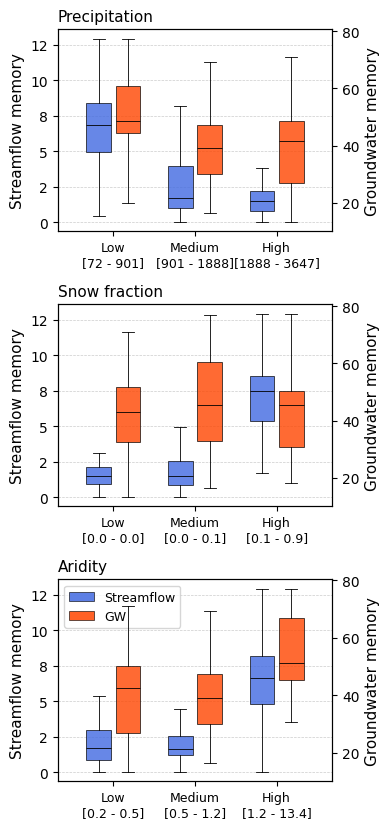

In [ ]:
# === Prepare data for boxplots ===
labels = ['Low', 'Medium', 'High']

def compute_monotonic_bins(series, n_bins):
    quantiles = np.linspace(0, 1, n_bins + 1)
    values = np.quantile(series, quantiles)
    eps = 1e-6
    for idx in range(1, len(values)):
        if values[idx] <= values[idx - 1]:
            values[idx] = values[idx - 1] + eps
            eps *= 10
    return values

def make_grouped_dataframe(data, attrib, id_col, column_map, prefix):
    frame = data.merge(attrib[[id_col] + list(column_map.values())], on=id_col, how='left')
    prefix_bins = {}
    for group_key, column in column_map.items():
        series = frame[column].dropna()
        if series.empty:
            bins = np.array([0.0, 1.0, 2.0, 3.0])
        else:
            bins = compute_monotonic_bins(series, len(labels))
        frame[f"{group_key}_group"] = pd.cut(frame[column], bins=bins, labels=labels, include_lowest=True)
        prefix_bins[f"{prefix}_{group_key}"] = {labels[i]: (float(bins[i]), float(bins[i + 1])) for i in range(len(bins) - 1)}
    return frame, prefix_bins

q_attributes = q_attrib[['gauge_id', 'p_mean_cr2met_1979_2010', 'frac_snow_cr2met_1979_2010', 'aridity_cr2met_1979_2010']].copy()
q_attributes['gauge_id'] = q_attributes['gauge_id'].astype(str)


q_box_df, q_group_bins = make_grouped_dataframe(
    q_data,
    q_attributes,
    'gauge_id',
    {
        'precip': 'p_mean_cr2met_1979_2010',
        'snow': 'frac_snow_cr2met_1979_2010',
        'aridity': 'aridity_cr2met_1979_2010',
    },
    prefix='q'
)

gw_attributes = gw_attrib[['cr2sub_id', 'cr2sub_camels_pr_yr', 'cr2sub_camels_sf', 'cr2sub_camels_aridity']].copy()
gw_attributes['cr2sub_id'] = gw_attributes['cr2sub_id'].astype(str)
gw_box_df, gw_group_bins = make_grouped_dataframe(
    gw_data,
    gw_attributes,
    'cr2sub_id',
    {
        'precip': 'cr2sub_camels_pr_yr',
        'snow': 'cr2sub_camels_sf',
        'aridity': 'cr2sub_camels_aridity',
    },
    prefix='gw'
)

group_bins = {**q_group_bins, **gw_group_bins}

def build_tick_labels(bin_key, categories, decimals):
    interval_map = group_bins.get(bin_key, {})
    labels_with_ranges = []
    fmt = f"{{:.{decimals}f}}"
    for cat in categories:
        interval = interval_map.get(cat)
        if interval:
            lower, upper = interval
            labels_with_ranges.append(f"{cat}\n[{fmt.format(lower)} - {fmt.format(upper)}]")
        else:
            labels_with_ranges.append(cat)
    return labels_with_ranges

# === Combined boxplots for streamflow and groundwater memories ===
combined_palette = {
    'streamflow': 'royalblue',
    'groundwater': 'orangered',
}

def plot_combined_dataset_boxplots(q_data, gw_data, q_value_col, gw_value_col, group_specs, q_ylabel, gw_ylabel, save_path):
    n_groups = len(group_specs)
    fig, axes = plt.subplots(n_groups, 1, figsize=(4, 2.8 * n_groups), sharey=True)
    if n_groups == 1:
        axes = [axes]
    else:
        axes = list(axes)

    for idx, (ax, (group_col, bin_key, decimals, title)) in enumerate(zip(axes, group_specs)):
        ax2 = ax.twinx()

        q_subset = q_data.dropna(subset=[group_col, q_value_col])
        gw_subset = gw_data.dropna(subset=[group_col, gw_value_col])
        category_order = [cat for cat in labels if (q_subset[group_col] == cat).any() or (gw_subset[group_col] == cat).any()]
        if not category_order:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            if idx == 0:
                ax.set_ylabel(q_ylabel)
                ax2.set_ylabel(gw_ylabel)
            ax.set_title(title, fontsize=10)
            continue

        positions = np.arange(1, len(category_order) + 1)
        offset = 0.18

        q_box_data = [q_subset.loc[q_subset[group_col] == cat, q_value_col] for cat in category_order]
        gw_box_data = [gw_subset.loc[gw_subset[group_col] == cat, gw_value_col] for cat in category_order]

        q_boxplot = ax.boxplot(
            q_box_data,
            positions=positions - offset,
            widths=0.3,
            showfliers=False,
            patch_artist=True,
        )
        gw_boxplot = ax2.boxplot(
            gw_box_data,
            positions=positions + offset,
            widths=0.3,
            showfliers=False,
            patch_artist=True,
        )

        for element in ('boxes', 'whiskers', 'caps'):
            for line_obj in q_boxplot[element]:
                line_obj.set_linewidth(0.6)
            for line_obj in gw_boxplot[element]:
                line_obj.set_linewidth(0.6)

        for median in q_boxplot['medians']:
            median.set_color('black')
            median.set_linewidth(0.6)
        for median in gw_boxplot['medians']:
            median.set_color('black')
            median.set_linewidth(0.6)

        for patch in q_boxplot['boxes']:
            patch.set_facecolor(combined_palette['streamflow'])
            patch.set_alpha(0.8)
        for patch in gw_boxplot['boxes']:
            patch.set_facecolor(combined_palette['groundwater'])
            patch.set_alpha(0.8)

        tick_labels = build_tick_labels(bin_key, category_order, decimals)
        ax.set_xticks(positions)
        ax.set_xticklabels(tick_labels, fontsize = 9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}"))
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}"))
        ax.set_ylabel(q_ylabel, fontsize = 11)
        ax2.set_ylabel(gw_ylabel, fontsize = 11)

        # if idx == 0:
        #     ax.set_ylabel(q_ylabel)
        #     ax2.set_ylabel(gw_ylabel)
        # else:
        #     ax.set_ylabel('')
        #     ax2.set_ylabel('')
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='0.8')
        ax.set_axisbelow(True)
        ax2.grid(False)
        ax.set_title(title, fontsize=11,loc='left')
        ax2.set_xlim(ax.get_xlim())

        if idx == 2:
            legend_handles = [
                Patch(facecolor=combined_palette['streamflow'], edgecolor='black', linewidth = 0.5, alpha=0.85, label='Streamflow'),
                Patch(facecolor=combined_palette['groundwater'], edgecolor='black', linewidth = 0.5, alpha=0.85, label='GW'),
            ]
            ax.legend(handles=legend_handles, loc='upper left', fontsize=9)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

combined_group_specs = [
    ('precip_group', 'q_precip', 0, 'Precipitation'),
    ('snow_group', 'q_snow', 1, 'Snow fraction'),
    ('aridity_group', 'q_aridity', 1, 'Aridity'),
]
combined_boxplot_output = 'Fig_memory_boxplots.png'
plot_combined_dataset_boxplots(
    q_box_df,
    gw_box_df,
    'q_memory',
    'gw_memory',
    combined_group_specs,
    'Streamflow memory',
    'Groundwater memory',
    combined_boxplot_output,
)


### Fig. Study Area 2-side map

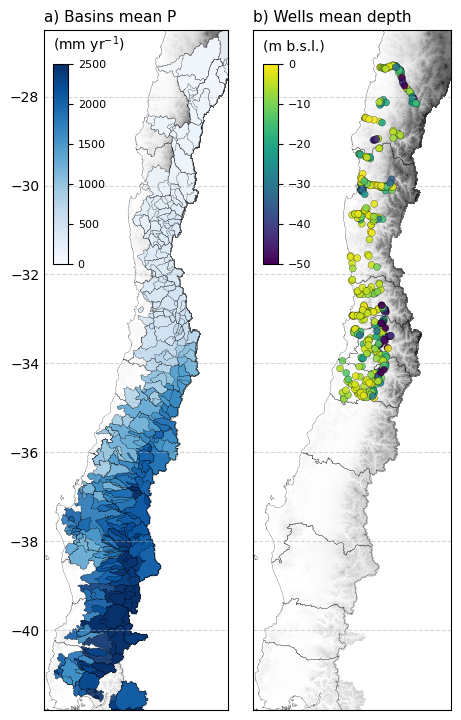

In [ ]:
# === Study area overview maps ===
basin_attrib1 = 'p_mean_cr2met_1979_2010'
basin_attrib2 = 'aridity_cr2met_1979_2010'
well_attrib1 = 'cr2sub_clean_mean_gwl'
well_attrib2 = 'cr2sub_clean_cv_gwl'

basin_attrs = q_attrib[['gauge_id', basin_attrib1, basin_attrib2]].copy()
basin_attrs['gauge_id'] = basin_attrs['gauge_id'].astype(str)

q_map = q_gpkg.copy()
q_map['gauge_id'] = q_map['gauge_id'].astype(str)
q_map = q_map.merge(basin_attrs, on='gauge_id', how='left')

gwl_gpkg_map = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
gw_map = gwl_gpkg_map.copy()
gw_map['cr2sub_id'] = gw_map['cr2sub_id'].astype(str)


fig = plt.figure(figsize=(12, 8))

width = 0.4
height = 0.85
x1 = 0.05
x2 = x1 + width - 0.22

ax1 = fig.add_axes([x1, 0.1, width, height])
ax2 = fig.add_axes([x2, 0.1, width, height])

for axis in (ax1, ax2):
    # axis.set_facecolor(to_rgba('powderblue', 0.3))
    elevation.plot(ax=axis, cmap='Greys', alpha=1, add_colorbar=False)
    regions_gdf.plot(ax=axis, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.yaxis.grid(True, linestyle='--', alpha=0.5)
    axis.xaxis.grid(False)
    axis.tick_params(axis='y', length=0)

    # for spine in axis.spines.values():
    #     spine.set_visible(False)

ax2.set_yticklabels([])
ax2.set_xticks([])
ax1.set_xticks([])

precip_valid = q_map.dropna(subset=[basin_attrib1])
if not precip_valid.empty:
    precip_norm = plt.Normalize(vmin=0, vmax=2500)
    precip_cmap = plt.cm.Blues
    precip_valid.plot(
        ax=ax1,
        column=basin_attrib1,
        cmap=precip_cmap,
        norm=precip_norm,
        linewidth=0.2,
        edgecolor='black',
        alpha=0.9,
    )
    sm_precip = plt.cm.ScalarMappable(norm=precip_norm, cmap=precip_cmap)
    sm_precip.set_array([])
    cax_precip = inset_axes(ax1, width="8%", height="35%", loc='upper left',
                            bbox_to_anchor=(0.05, 0.11, 1, .84), bbox_transform=ax1.transAxes, borderpad=0)
    cbar_precip = plt.colorbar(sm_precip, cax=cax_precip, orientation='vertical')
    cbar_precip.ax.set_title(r'(mm yr$^{-1}$)', fontsize=10, loc='left', pad = 10)
    cbar_precip.ax.tick_params(labelsize=8)
ax1.set_title('a) Basins mean P', fontsize=11, loc='left')


gw_valid = gw_map.dropna(subset=[well_attrib1])
if not gw_valid.empty:
    gw_norm = plt.Normalize(vmin=-50, vmax=0)
    gw_cmap = plt.cm.viridis
    gw_valid.plot(
        ax=ax2,
        column=well_attrib1,
        cmap=gw_cmap,
        norm=gw_norm,
        markersize=25,
        edgecolor='black',
        linewidth=0.2,
        alpha=0.9,
    )
    sm_gw = plt.cm.ScalarMappable(norm=gw_norm, cmap=gw_cmap)
    sm_gw.set_array([])
    cax_gw = inset_axes(ax2, width="8%", height="35%", loc='upper left',
                        bbox_to_anchor=(0.05, 0.11, 1, .84), bbox_transform=ax2.transAxes, borderpad=0)
    cbar_gwl = plt.colorbar(sm_gw, cax=cax_gw, orientation='vertical')
    cbar_gwl.ax.set_title('(m b.s.l.)', fontsize=10, loc='left', pad = 10)
    cbar_gwl.ax.tick_params(labelsize=8)
ax2.set_title('b) Wells mean depth', fontsize=11, loc='left')

plt.savefig('Fig_study_area_2side_map.png', dpi=300, bbox_inches='tight')
plt.show()


### Fig. 1 ms - Study Area 4-side map

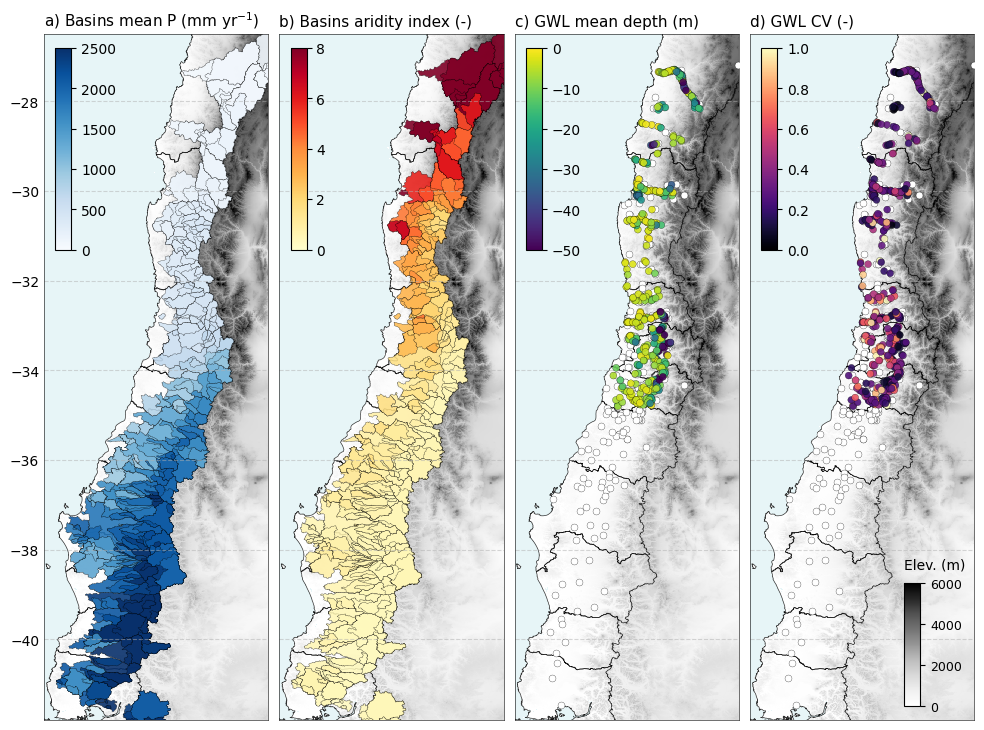

In [ ]:
# === Study area overview maps (4 panels) ===
basin_attrib1 = 'p_mean_cr2met_1979_2010'
basin_attrib2 = 'aridity_cr2met_1979_2010'
well_attrib1 = 'cr2sub_clean_mean_gwl'
well_attrib2 = 'cr2sub_clean_cv_gwl'

attribute_norms = {
    basin_attrib1: plt.Normalize(vmin=0, vmax=2500),
    basin_attrib2: plt.Normalize(vmin=0, vmax=8),
    well_attrib1: plt.Normalize(vmin=-50, vmax=0),
    well_attrib2: plt.Normalize(vmin=0, vmax=1),
}

basin_attrs = q_attrib[['gauge_id', basin_attrib1, basin_attrib2]].copy()
basin_attrs['gauge_id'] = basin_attrs['gauge_id'].astype(str)

q_map = q_gpkg.copy()
q_map['gauge_id'] = q_map['gauge_id'].astype(str)
q_map = q_map.merge(basin_attrs, on='gauge_id', how='left')

gwl_gpkg_map = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
gw_map = gwl_gpkg_map.copy()
gw_map['cr2sub_id'] = gw_map['cr2sub_id'].astype(str)

plot_specs = [
    {
        'title': 'a) Basins mean P ' r'(mm yr$^{-1}$)',
        'data': q_map,
        'column': basin_attrib1,
        'map_type': 'polygon',
        'cmap': plt.cm.Blues,
        'colorbar_label': r'(mm yr$^{-1}$)'
    },
    {
        'title': 'b) Basins aridity index (-)',
        'data': q_map,
        'column': basin_attrib2,
        'map_type': 'polygon',
        'cmap': plt.cm.YlOrRd,
        'colorbar_label': '(-)'
    },
    {
        'title': 'c) GWL mean depth (m)',
        'data': gw_map,
        'column': well_attrib1,
        'map_type': 'point',
        'cmap': plt.cm.viridis,
        'colorbar_label': '(m b.s.l.)'
    },
    {
        'title': 'd) GWL CV (-)',
        'data': gw_map,
        'column': well_attrib2,
        'map_type': 'point',
        'cmap': plt.cm.magma,
        'colorbar_label': '(-)'
    },
]

fig, axes = plt.subplots(1, 4, figsize=(12, 10), constrained_layout=False)
fig.subplots_adjust(wspace=0.05)

axes = axes.flatten()

min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5

# Customize elevation stretch (set explicit limits or keep None to auto-range)
elevation_vmin = 0
elevation_vmax = 6000
elevation_cmap = plt.cm.Greys

# Select which DEM to draw (set to elevation_etopo to use global ETOPO background)
# elevation_background = elevation
elevation_background = elevation_etopo

lat_dim_candidates = ('latitude', 'lat', 'y')
lon_dim_candidates = ('longitude', 'lon', 'x')

if elevation_vmin is not None or elevation_vmax is not None:
    elev_vmin = elevation_vmin if elevation_vmin is not None else float(np.nanmin(elevation_background.values))
    elev_vmax = elevation_vmax if elevation_vmax is not None else float(np.nanmax(elevation_background.values))
else:
    elev_vmin = float(np.nanmin(elevation_background.values))
    elev_vmax = float(np.nanmax(elevation_background.values))
elevation_norm = plt.Normalize(vmin=elev_vmin, vmax=elev_vmax)

def plot_elevation_background(axis, data):
    if hasattr(data, 'dims'):
        dims = list(data.dims)
        lat_name = next((d for d in dims if any(key in d.lower() for key in lat_dim_candidates)), None)
        lon_name = next((d for d in dims if any(key in d.lower() for key in lon_dim_candidates)), None)
        if lat_name is None or lon_name is None:
            raise ValueError('Could not infer latitude/longitude dimension names for elevation DataArray.')
        arr = data.transpose(lat_name, lon_name).values
        lat_vals = data.coords[lat_name].values
        lon_vals = data.coords[lon_name].values
    else:
        raise TypeError('Elevation object must be an xarray.DataArray with lat/lon coordinates.')

    lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

    land = np.where(arr <= 0, np.nan, arr)
    axis.pcolormesh(lon_grid, lat_grid, land, shading='auto', cmap=elevation_cmap, norm=elevation_norm)

for axis in axes:
    plot_elevation_background(axis, elevation_background)
    regions_gdf.plot(ax=axis, edgecolor='black', facecolor='none', linewidth=0.5, alpha=0.8)
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.yaxis.grid(True, linestyle='--', alpha=0.5)
    axis.xaxis.grid(False)
    axis.tick_params(axis='both', length=0)

    # === Plot blue ocean background ===
    axis.set_facecolor(to_rgba('powderblue', 0.3))

    for spine in axis.spines.values():
        spine.set_linewidth(0.4)
        
for axis in (axes[1], axes[2],axes[3]):
    axis.set_yticklabels([])
for axis in axes:
    axis.set_xticklabels([])

for axis, spec in zip(axes, plot_specs):
    df = spec['data'].copy()
    axis.set_title(spec['title'], fontsize=11, loc='left')

    norm = attribute_norms.get(spec['column'])
    
    if spec['map_type'] == 'polygon':
        df.plot(
            ax=axis,
            column=spec['column'],
            cmap=spec['cmap'],
            norm=norm,
            linewidth=0.2,
            edgecolor='black',
            alpha=0.9,
        )
    else:
        valid_points = df.dropna(subset=[spec['column']])
        if not valid_points.empty:
            valid_points.plot(
                ax=axis,
                column=spec['column'],
                cmap=spec['cmap'],
                norm=norm,
                markersize=25,
                edgecolor='black',
                linewidth=0.2,
                alpha=0.9,
                zorder=10,
            )
        missing_points = df[df[spec['column']].isna()]
        if not missing_points.empty:
            missing_points.plot(
                ax=axis,
                color='white',
                edgecolor='black',
                markersize=25,
                linewidth=0.2,
                zorder=5,
            )

    sm = plt.cm.ScalarMappable(norm=norm, cmap=spec['cmap'])
    sm.set_array([])
    cax = inset_axes(axis, width="8%", height="35%", loc='upper left',
                 bbox_to_anchor=(0.05, 0.14, .9, .84),
                 bbox_transform=axis.transAxes, borderpad=0)
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
    # cbar.ax.set_title(spec['colorbar_label'], fontsize=10, loc='left', pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Re-apply consistent limits/aspect in case GeoPandas reset them
    axis.set_xlim(min_lon, max_lon)
    axis.set_ylim(min_lat, max_lat)
    axis.set_aspect('equal', adjustable='box')
    axis.set_anchor('C')

# Add DEM colorbar on the rightmost panel
sm_elev = plt.cm.ScalarMappable(norm=elevation_norm, cmap=elevation_cmap)
sm_elev.set_array([])
cax_elev = inset_axes(axes[2], width="8%", height="20%", loc='lower right',
                     bbox_to_anchor=(0.91, 0.02, .9, .9),
                     bbox_transform=axes[2].transAxes, borderpad=0)
cbar_elev = plt.colorbar(sm_elev, cax=cax_elev, orientation='vertical')
cbar_elev.ax.set_title('Elev. (m)', fontsize=10, loc='left', pad=10)
cbar_elev.ax.tick_params(labelsize=9)

# plt.savefig('Fig_study_area_4panel_map.png', dpi=300)
plt.savefig('Fig_study_area_4panel_map.png', dpi=300, bbox_inches='tight')
plt.show()





### Fig.2 ms - Data availabiliyy

/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_794/1332659418.py:82: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(regions_gw, axis=1).mean()
/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_794/1332659418.py:95: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(regions_q, axis=1).mean()


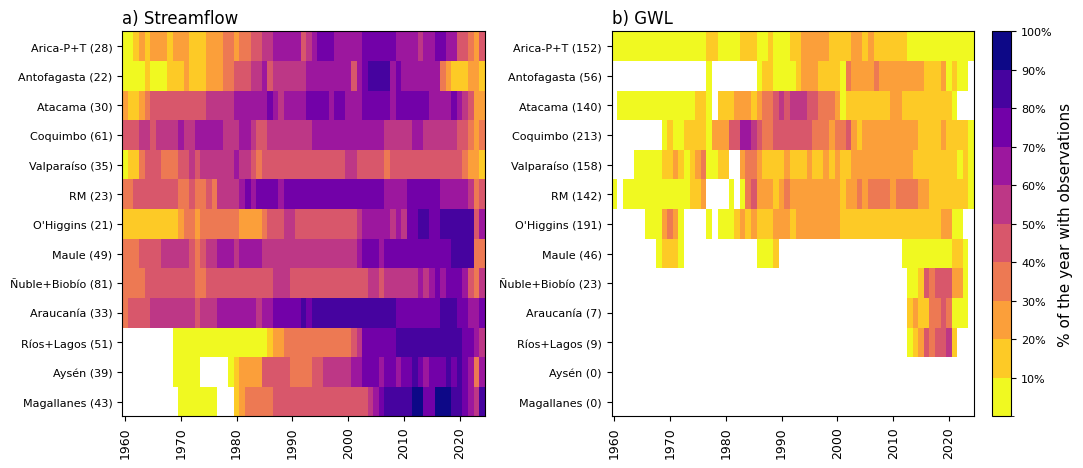

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.colors import BoundaryNorm

# -------------------- Paths --------------------
data_dir = '/Users/cag/Dropbox/0_Research/0_githubs/ms_recovery/data'
ms_data_dir = f'{data_dir}/cr2sub'
camels_dir  = f'{data_dir}/camels'

# -------------------- 1) Cargar series (date index, sin columnas duplicadas) --------------------
gw_df = pd.read_csv(f'{ms_data_dir}/cr2sub_v1.1_gwl_mon.csv', parse_dates=['date']).set_index('date')
q_df  = pd.read_csv(f'{camels_dir}/camels_q_mm.csv',            parse_dates=['date']).set_index('date')
gw_df = gw_df.loc[:, ~gw_df.columns.duplicated()]
q_df  = q_df.loc[:,  ~q_df.columns.duplicated()]


# -------------------- Región: orden + códigos --------------------
REGION_NAME_ORDER = [
    'Arica-P+T','Antofagasta','Atacama','Coquimbo','Valparaíso','RM',"O'Higgins",
    'Maule','Ñuble+Biobío','Araucanía','Ríos+Lagos','Aysén','Magallanes'
]
REGION_SORT_ORDER = {name: i for i, name in enumerate(REGION_NAME_ORDER)}

REGION_CODE_TO_LABEL = {
    1:'Arica-P+T', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso',
    6:"O'Higgins", 7:'Maule', 8:'Ñuble+Biobío', 9:'Araucanía', 10:'Ríos+Lagos',
    11:'Aysén', 12:'Magallanes', 13:'RM'
}

def extract_region(code):
    """Dado un código/colname (tipo DGA), infiere región según tu regla."""
    s = str(code)
    digits = ''.join(ch for ch in s if ch.isdigit())
    if len(digits) >= 8: #e.g., 103400012
        prefix = int(digits[:2])
    elif digits and digits[0] == '5':
        prefix = int(digits[:2])
    else:
        prefix = int(digits[0]) # 1,2,3,4 + 6,7,8,9
        
    if 51 <= prefix <= 56:
        return 'Valparaíso'
    if prefix in (57, 58):
        return 'RM'
    return REGION_CODE_TO_LABEL.get(prefix, str(prefix))

# -------------------- 2) conteos por región --------------------
gw_region_map = {}
for c in gw_df.columns:
    try:
        gw_region_map[c] = extract_region(c)
    except Exception:
        pass

q_region_map = {}
for c in q_df.columns:
    try:
        q_region_map[c] = extract_region(c)
    except Exception:
        pass

gw_counts = Counter(gw_region_map.values())
q_counts  = Counter(q_region_map.values())

# Orden final de regiones (unión Q + GW, en tu orden predefinido)
regions_all = sorted(set(gw_counts.keys()).union(q_counts.keys()),
                     key=lambda r: REGION_SORT_ORDER.get(r, 1e9))


# disponibilidad mensual (1 = dato, 0 = missing) → promedio anual
min_year, max_year = 1960, 2024
years_full = np.arange(min_year, max_year + 1)

# -------- Groundwater --------
regions_gw = pd.Series({c: extract_region(c) for c in gw_df.columns})

gw_cov = (
    gw_df.notna().astype(float)
        .resample('YE').mean()
        .groupby(regions_gw, axis=1).mean()
)

gw_cov.index = gw_cov.index.year
gw_cov = gw_cov.reindex(years_full).reindex(columns=regions_all)


# -------- Streamflow --------
regions_q = pd.Series({c: extract_region(c) for c in q_df.columns})

q_cov = (
    q_df.notna().astype(float)
        .resample('YE').mean()
        .groupby(regions_q, axis=1).mean()
)

q_cov.index = q_cov.index.year
q_cov = q_cov.reindex(years_full).reindex(columns=regions_all)


# -------- Matrices para pcolormesh --------
q_mat, years_q   = q_cov.values.T, q_cov.index.values
gw_mat, years_gw = gw_cov.values.T, gw_cov.index.values


# -------------------- 4) Plot (dos paneles) --------------------
bins = np.linspace(0, 1, 11)                          # 0–100% en 10 bins
tick_pos = bins[1:]
tick_lab = [f"{int(b*100)}%" for b in tick_pos]
cmap = plt.get_cmap('plasma_r', len(bins)-1).copy()
cmap.set_bad(color='white')
norm = BoundaryNorm(bins, cmap.N)

def labels_with_counts(regions, counts):
    return [f"{r} ({counts.get(r,0)})" for r in regions]

fig, (ax_q, ax_gw) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
fig.subplots_adjust(wspace=0.35, right=0.88)

for ax, mat, years, title, counts in [
    (ax_q,  q_mat,  years_q,  "a) Streamflow", q_counts),
    (ax_gw, gw_mat, years_gw, "b) GWL",       gw_counts),
]:
    if mat.size == 0 or years.size == 0:
        ax.text(0.5, 0.5, "Sin datos", ha='center', va='center')
        ax.axis('off')
        continue

    # Enmascarar NaN y ceros (si 0 significa “sin dato” en tu caso)
    masked = np.ma.masked_where(~np.isfinite(mat) | (mat <= 0), mat)

    # Bordes para pcolormesh (años en x, regiones en y)
    x_edges = np.linspace(years.min()-0.5, years.max()+0.5, len(years)+1)
    y_edges = np.arange(-0.5, len(regions_all)+0.5, 1)
    X, Y = np.meshgrid(x_edges, y_edges)

    im = ax.pcolormesh(X, Y, masked, cmap=cmap, norm=norm, shading='auto',
                       edgecolors='lightgray', linewidth=0.001)

    ax.set_title(title, loc='left')
    ax.set_yticks(np.arange(len(regions_all)))
    ax.set_yticklabels(labels_with_counts(regions_all, counts), fontsize=8)
    ax.set_ylim(len(regions_all)-0.5, -0.5)

    # ticks cada 10 años
    start = (years.min()//10)*10
    end   = (years.max()//10)*10
    decades = np.arange(start, end+10, 10)
    decades = decades[(decades >= years.min()) & (decades <= years.max())]
    ax.set_xticks(decades)
    ax.set_xticklabels(decades, rotation=90, ha='center', fontsize=9)

# colorbar común
cb = fig.colorbar(im, ax=[ax_q, ax_gw], orientation='vertical',
                  pad=0.02, fraction=0.04, ticks=tick_pos)
cb.ax.set_yticklabels(tick_lab)
cb.set_label('% of the year with observations', fontsize=11)
cb.ax.tick_params(labelsize=8)

plt.savefig('Fig_data_availability.png', dpi=300, bbox_inches='tight')
plt.show()

### Fig.4 ms - P/Q/GWL seasonality

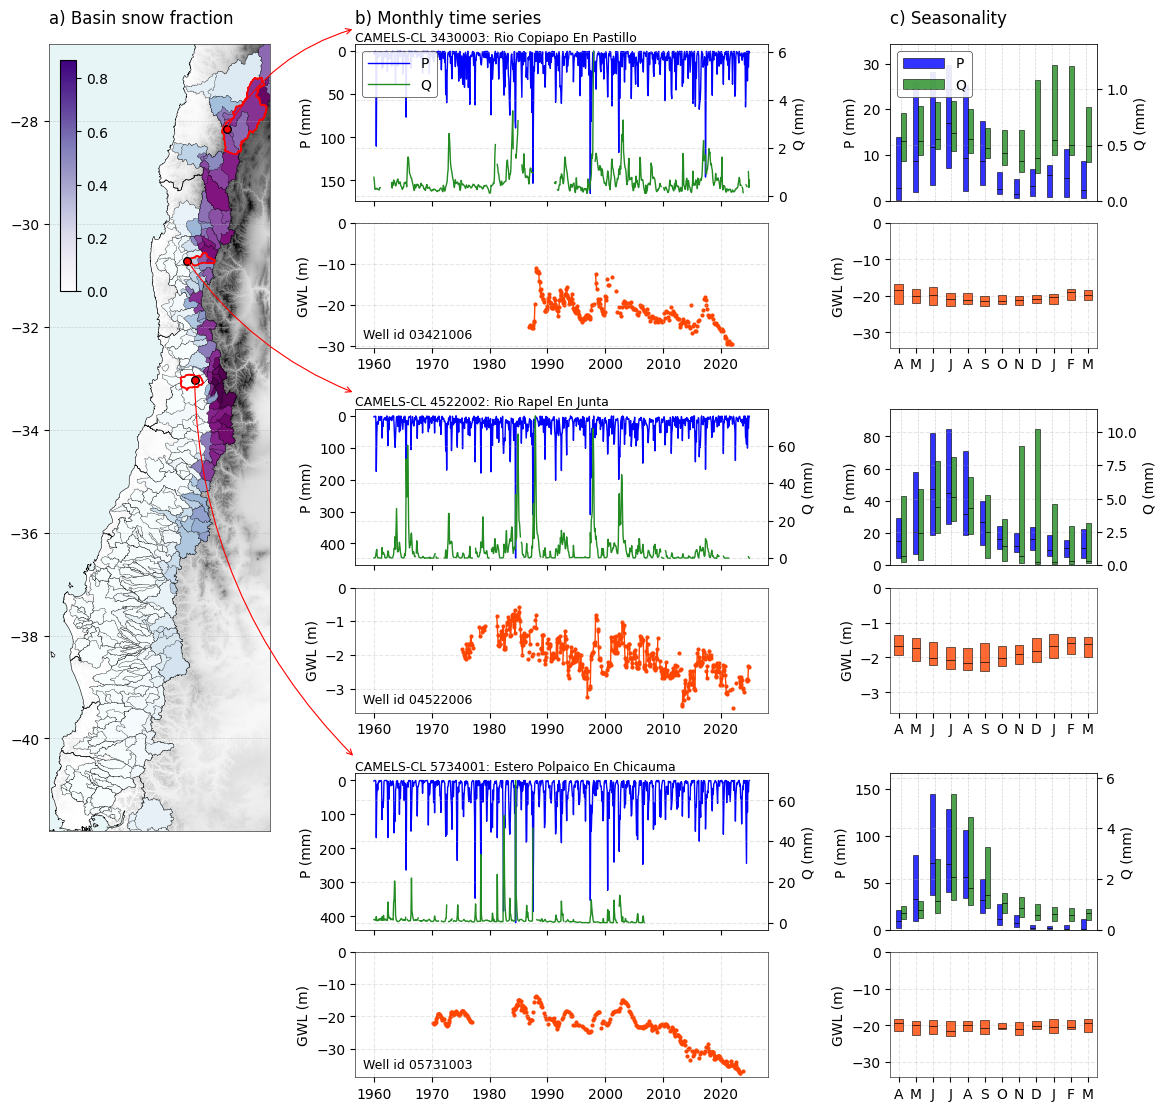

In [78]:
import matplotlib.gridspec as gridspec
from pathlib import Path
from matplotlib.colors import to_rgba
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# 0) Configuración
# =========================
# well_codes = ['03421006', '05731003', '06015017']
# well_codes = ['03421006', '04550006', '06011014']
well_codes = ['03421006', '04522006', '05731003']
months_order = list(range(4, 13)) + list(range(1, 4))                 # Abr..Dic + Ene..Mar
month_labels = ['A','M','J','J','A','S','O','N','D','J','F','M']       # para eje x
boxplot_cutoff = pd.Timestamp('2010-01-01')                            # usar datos < 2010
n_wells = len(well_codes)

# col_p  = 'mediumblue'
# col_q  = 'mediumvioletred'
# col_gw = 'peru'

col_p  = 'blue'
col_q  = 'forestgreen'
col_gw = 'orangered'

date_range = pd.date_range('1960-01-01', '2024-12-01', freq='MS')      # mensual

# =========================
# 1) Cargar datos (series + atributos + shapes)
# =========================
data_dir = Path('../data')
gwl = pd.read_csv(data_dir/'cr2sub/cr2sub_v1.1_gwl_mon_clean.csv', parse_dates=['date']).set_index('date'); gwl.columns=gwl.columns.astype(str)
pr  = pd.read_csv(data_dir/'camels/camels_pr_mm.csv', parse_dates=['date']).set_index('date'); pr.columns=pr.columns.astype(str)
q   = pd.read_csv(data_dir/'camels/camels_q_mm.csv', parse_dates=['date']).set_index('date'); q.columns=q.columns.astype(str)
attr = pd.read_csv(data_dir/'cr2sub/cr2sub_v1.1_attributes.csv')

attr['cr2sub_id']  = attr['cr2sub_id'].astype(int).astype(str)
attr['cr2sub_in_basin_camels'] = attr['cr2sub_in_basin_camels'].astype(float).astype('Int64').astype(str)

camels_shapes = gpd.read_file(camels_dir / 'CAMELScl_boundaries_epsg4326.gpkg')
camels_shapes['gauge_id'] = camels_shapes['gauge_id'].astype(str)

camels_attrs = pd.read_csv(camels_dir / 'catchment_attributes.csv')[
    ['gauge_id', 'gauge_name', 'frac_snow_cr2met_1979_2010', 'area_km2']
]
camels_attrs['gauge_id'] = camels_attrs['gauge_id'].astype(str)

map_gdf = camels_shapes.merge(camels_attrs, on='gauge_id', how='left')
map_gdf = map_gdf.sort_values(by='area_km2', ascending=False)

regions = gpd.read_file(data_dir / 'other' / 'cl_regiones_geo' / 'cl_regiones_geo.shp')
well_points = gpd.GeoDataFrame(
    attr,
    geometry=gpd.points_from_xy(attr['cr2sub_lon'], attr['cr2sub_lat']),
    crs='EPSG:4326'
)

# DEM para fondo
dem = xr.open_dataset(data_dir / 'other' / 'ETOPO_2022_v1_30s_N90W180_bed.nc')['z']
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
dem = dem.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))
dem_masked = np.ma.masked_less_equal(dem.values, 0)

# --- Helpers ---
def norm_code(code):
    digits = ''.join(ch for ch in str(code) if ch.isdigit())
    stripped = digits.lstrip('0')
    return stripped or digits or str(code)

well_lookup = {code: norm_code(code) for code in well_codes}
date_range = pd.date_range('1960-01-01', '2024-12-31', freq='MS')

# --- Figure layout (original proportions) ---
# panel_labels_ts = ['b.1', 'c.1', 'd.1']          # títulos para las series P/Q
# panel_labels_box = ['b.2', 'c.2', 'd.2'] 

panel_labels_ts = ['b) Monthly time series']          # títulos para las series P/Q
panel_labels_box = ['c) Seasonality'] 

fig = plt.figure(figsize=(11, 11), constrained_layout=True)
outer_gs = gridspec.GridSpec(n_wells * 2 + 1, 2, width_ratios=[1.6, 6], figure=fig)

map_rows = 7  # 
ax_map = fig.add_subplot(outer_gs[:map_rows, 0], frameon=True)
ax_map.set_facecolor(to_rgba('powderblue', 0.3))
ax_map.set_title('a) Snow fraction map', loc='left')

lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)  # leave oceans/flat areas blank

ax_map.pcolormesh(lon_grid, lat_grid, dem_masked, shading='auto', cmap=elevation_cmap, norm=elevation_norm)
regions.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.4)
  
snow_column = 'frac_snow_cr2met_1979_2010'
snow_values = map_gdf[snow_column]
snow_norm = plt.Normalize(vmin=snow_values.min(), vmax=snow_values.max())
map_gdf.plot(
    ax=ax_map,
    column=snow_column,
    cmap='BuPu',
    linewidth=0.2,
    edgecolor='black'
)

ax_map.yaxis.set_ticks_position('left')
ax_map.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
ax_map.tick_params(axis='y', right=False, labelright=False)
ax_map.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

for spine in ax_map.spines.values():
    spine.set_linewidth(0.5)              # ajusta el valor (0.5, 0.3, etc.)
    spine.set_edgecolor('0.2')            # opcional: color más suave


sm = plt.cm.ScalarMappable(norm=snow_norm, cmap='Purples')
sm.set_array([])
cax = inset_axes(
    ax_map, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.14, .9, .84),
    bbox_transform=ax_map.transAxes, borderpad=0
)
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=10)

ax_map.set_xlim(min_lon, max_lon)
ax_map.set_ylim(min_lat, max_lat)
ax_map.set_title('a) Basin snow fraction', loc='left', pad = 15)
ax_map.set_anchor('NW')

height_ratios = []
for _ in range(n_wells):
    height_ratios.extend([1, 0.8, 0.1])
height_ratios = height_ratios[:-1]

inner_gs = gridspec.GridSpecFromSubplotSpec(
    len(height_ratios), 2,
    subplot_spec=outer_gs[:, 1],
    height_ratios=height_ratios,
    width_ratios=[4, 2],
    hspace=0.03,
    wspace=0.03
)

used_gauges = []
used_wells = []

def monthly_arrays(series):
    clean = series[series.index < boxplot_cutoff].dropna()
    grouped = clean.groupby(clean.index.month)
    monthly_data = [grouped.get_group(m).values if m in grouped.groups else [] for m in months_order]

    monthly_p75 = []
    monthly_p25 = []
    for arr in monthly_data:
        if len(arr):
            monthly_p75.append(np.nanpercentile(arr, 75))
            monthly_p25.append(np.nanpercentile(arr, 25))
        else:
            monthly_p75.append(np.nan)
            monthly_p25.append(np.nan)

    valid_p75 = [v for v in monthly_p75 if not np.isnan(v)]
    valid_p25 = [v for v in monthly_p25 if not np.isnan(v)]
    max_p75 = max(valid_p75) if valid_p75 else np.nan
    min_p25 = min(valid_p25) if valid_p25 else np.nan

    return monthly_data, max_p75, min_p25


ts_axes = []

for idx, raw_code in enumerate(well_codes):
    # 2) Dentro del loop:
    label_idx = 1 + idx   # porque para cada pozo tienes 4 paneles (P/Q TS, GW TS, P/Q boxes, GW boxes)

    code = well_lookup[raw_code]
    match = attr[attr['cr2sub_id'] == code]
    if match.empty:
        continue
    gauge_id = str(int(match['cr2sub_in_basin_camels'].iloc[0]))
    basin_name = camels_attrs[camels_attrs['gauge_id'] == gauge_id]['gauge_name'].iloc[0]
    if code not in gwl.columns or gauge_id not in pr.columns or gauge_id not in q.columns:
        continue

    gwl_series = gwl[code].reindex(date_range)
    pr_series = pr[gauge_id].reindex(date_range)
    q_series = q[gauge_id].reindex(date_range)

    row_ts = idx * 3
    row_box = row_ts + 1

    ax_ts = fig.add_subplot(inner_gs[row_ts, 0])
    ts_axes.append(ax_ts)
    
    ax_ts.plot(pr_series.index, pr_series, color=col_p, lw=1)
    ax_ts.invert_yaxis()
    ax_ts.set_ylabel('P (mm)')
    ax_ts.tick_params(axis='x', labelbottom=False)
    # ax_ts.set_title(f"{panel_labels_ts[idx]}) CAMELS-CL {gauge_id}: {basin_name}", loc='left')   
    if idx == 0:    
        ax_ts.set_title("b) Monthly time series", loc='left', pad=15)   
    
    ax_ts.text(
        0.0, 1,
        f"CAMELS-CL {gauge_id}: {basin_name}",
        transform=ax_ts.transAxes,
        ha='left',
        va='bottom',
        fontsize=9
    )
             
    ax_q = ax_ts.twinx()
    ax_q.plot(q_series.index, q_series, color=col_q, lw=1)
    ax_q.set_ylabel('Q (mm)')
    ax_q.grid(True, linestyle='--', alpha=0.3)
    

    if idx == 0:
        legend_handles = [
            ax_ts.lines[0],
            ax_q.lines[0],
            # ax_gw.lines[0],
        ]
        legend_labels = ['P', 'Q']
        legend = ax_ts.legend(
            legend_handles,
            legend_labels,
            loc='upper left',
            frameon=True,
            fontsize=10,
            handlelength=3,
        )
        legend.get_frame().set_linewidth(0.6)   # grosor fino
        legend.get_frame().set_edgecolor('0.3') # color suave opcional
        legend.get_frame().set_alpha(0.9)       # opcional   
      
  
    ax_gw = fig.add_subplot(inner_gs[row_box, 0], sharex=ax_ts)
    ax_gw.plot(gwl_series.index, gwl_series, color=col_gw, lw=1)
    ax_gw.scatter(gwl_series.index, gwl_series, color=col_gw, s=4)
    ax_gw.set_ylabel('GWL (m)')
    ax_gw.set_ylim(top=0)
    ax_gw.grid(True, linestyle='--', alpha=0.3)
    ax_gw.tick_params(axis='x', labelbottom=True)
     
    # anotación dentro del panel (abajo izquierda)
    ax_gw.text(0.02, 0.05,f"Well id {raw_code}",transform=ax_gw.transAxes,ha='left',va='bottom',fontsize=9)

    # calculos para boxplots
    pr_data, pr_p75, pr_p25 = monthly_arrays(pr_series)
    q_data, q_p75, q_p25 = monthly_arrays(q_series)
    gw_data, gw_p75, gw_p25 = monthly_arrays(gwl_series)

    ylim_max1 = pr_p75 * 1.15 if not np.isnan(pr_p75) else 1
    ylim_max2 = q_p75 * 1.15 if not np.isnan(q_p75) else 1
    ylim_max3 = gw_p25 * 1.5 if not np.isnan(gw_p25) else -1

    ax_box = fig.add_subplot(inner_gs[row_ts, 1])
    bp_p = ax_box.boxplot(
        pr_data,
        positions=[x - 0.15 for x in range(1, 13)],
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=col_p, alpha=0.8, linewidth=0.5),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
        medianprops=dict(color='black', linewidth=0.5)
    )
    ax_box.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax_box.set_ylabel('P (mm)')
    # ax_box.set_title('Seasonality', loc='left')
    ax_box.set_ylim(0, ylim_max1)
    for month in range(1, 13):
        ax_box.axvline(month, color='lightgray', linestyle='--', linewidth=0.5, zorder=0)

    # ax_box.set_title(f'{panel_labels[label_idx+2]}) Seasonality', loc='left')
    if idx == 0:  
        ax_box.set_title("c) Seasonality", loc='left', pad = 15)
    
    ax_box_q = ax_box.twinx()
    bp_q = ax_box_q.boxplot(
        q_data,
        positions=[x + 0.15 for x in range(1, 13)],
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=col_q, alpha=0.8, linewidth=0.5),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
        medianprops=dict(color='black', linewidth=0.5)
    )
    ax_box_q.set_ylabel('Q (mm)')
    ax_box_q.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax_box_q.set_ylim(0, ylim_max2)
       
    if idx == 0:
        legend_handles = [
            bp_p['boxes'][0],
            bp_q['boxes'][0],
            # ax_gw.lines[0],
        ]
        legend_labels = ['P', 'Q']
        legend = ax_box.legend(
            legend_handles,
            legend_labels,
            loc='upper left',
            frameon=True,
            fontsize=10,
            handlelength=3,
        )
        legend.get_frame().set_linewidth(0.6)   # grosor fino
        legend.get_frame().set_edgecolor('0.3') # color suave opcional
        legend.get_frame().set_alpha(0.9)       # opcional   
        
        
    ax_box_gw = fig.add_subplot(inner_gs[row_box, 1])
    ax_box_gw.boxplot(
        gw_data,
        positions=range(1, 13),
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=col_gw, alpha=0.8, linewidth=0.5),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
        medianprops=dict(color='black', linewidth=0.5)
    )
    ax_box_gw.set_xticks(range(1, 13))
    ax_box_gw.set_xticklabels(month_labels)
    ax_box_gw.set_ylabel('GWL (m)')
    ax_box_gw.grid(True, linestyle='--', alpha=0.3)
    ax_box_gw.set_ylim(ylim_max3, 0)
    # ax_box_gw.set_title(f'{panel_labels[label_idx+3]}) GW seasonality', loc='left')
    
    for ax in [ax_ts, ax_q, ax_gw, ax_box, ax_box_q, ax_box_gw]:
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)
        
       
# polígonos rojos para destacar basins y pozos seleccionados
    used_gauges.append(gauge_id)
    used_wells.append(code)
    
selected_basins = map_gdf[map_gdf['gauge_id'].isin(used_gauges)]
if not selected_basins.empty:
    selected_basins.plot(ax=ax_map, facecolor='none', edgecolor='red', linewidth=1.2)
selected_wells = well_points[well_points['cr2sub_id'].isin(used_wells)]
if not selected_wells.empty:
    selected_wells.plot(ax=ax_map, color='red', markersize=30, edgecolor='black')

# === Draw arrows from basin centroid (map) to time series title ===
for i, cod in enumerate(well_codes):
    match = attr[attr['cr2sub_id'] == norm_code(cod)]
    if match.empty or i >= len(ts_axes):
        continue
    well_geom = well_points[well_points['cr2sub_id'] == norm_code(cod)].geometry.values[0]

    if i == 0:
        curve_rad = -0.2  # curve downward
    if i == 1:
        curve_rad = 0.15  # curve downward
    if i == 2:
        curve_rad = 0.2   # keep upward
        
    ax_map.annotate(
        '',
        xy=(0, 1.1), xycoords=ts_axes[i].transAxes,
        xytext=(well_geom.x, well_geom.y), textcoords='data',
        arrowprops=dict(
            arrowstyle='->',
            lw=.8,
            color='red',
            connectionstyle=f"arc3,rad={curve_rad}",
        ),
        annotation_clip=False,
    )
    
# Manually adjust layout to prevent map from being pushed off-screen
ax_map.set_position([
    ax_map.get_position().x0-0.05,
    ax_map.get_position().y0,
    ax_map.get_position().width,
    ax_map.get_position().height
])


        
plt.savefig('Fig_P_Q_GW_ts_seasonality.png', dpi=600, bbox_inches='tight')
plt.show()


### Fig.5 ms - R2 LR models 2-side map + ts

/var/folders/mm/nd9j2p7s4d1fmw46jbmnzdvr0000gn/T/ipykernel_794/1156231309.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_list = cm.get_cmap('viridis')(np.linspace(0, 1, len(bins) - 1))


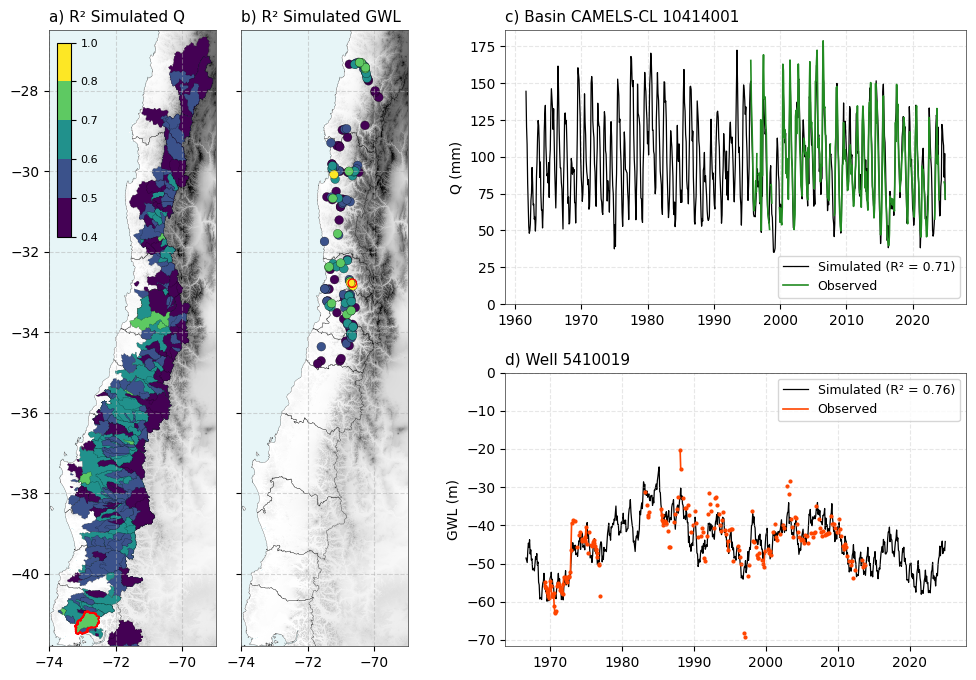

In [163]:
######### MAP R2 performance LR models + monthly time series #########

# === load data ===
q_r2_df = pd.read_csv('../analysis/4_GW_Q_memory/csv/q_memory.csv')
gw_r2_df = pd.read_csv('../analysis/4_GW_Q_memory/csv/gw_memory.csv')
gw_attrib = pd.read_csv('../data/cr2sub/cr2sub_v1.1_attributes.csv').rename(columns={'cr2sub_id': 'well_id'})
q_attrib = pd.read_csv('../data/camels/catchment_attributes.csv')
path_netcdf = '../data/other/elevation_srtm_v4.1_Chile_2000_1200m_epsg4326.nc'

# simulaciones históricas
q_sim = pd.read_csv('../analysis/5_recovery/csv/q_sim_hist.csv', parse_dates=['date']).set_index('date')
gw_sim = pd.read_csv('../analysis/5_recovery/csv/gw_sim_hist.csv', parse_dates=['date']).set_index('date')
q_sim.columns = q_sim.columns.astype(str)
gw_sim.columns = gw_sim.columns.astype(str)

# === Load the GeoPackage files ===
gwl_gpkg = gpd.GeoDataFrame(
    gw_attrib,
    geometry=gpd.points_from_xy(gw_attrib['cr2sub_lon'], gw_attrib['cr2sub_lat']),
    crs='EPSG:4326'
)
q_gpkg = gpd.read_file('../data/camels/CAMELScl_boundaries_epsg4326.gpkg')

# asegurar mismo tipo de IDs antes del merge
q_r2_df['gauge_id'] = q_r2_df['gauge_id'].astype(str)
gw_r2_df['well_id'] = gw_r2_df['well_id'].astype(str)
q_gpkg['gauge_id'] = q_gpkg['gauge_id'].astype(str)
gwl_gpkg['well_id'] = gwl_gpkg['well_id'].astype(str)

# merge de r2 al geodataframe
q_gpkg = q_gpkg.merge(
    q_r2_df[['gauge_id', 'max_r2_selected_configs']],
    on='gauge_id',
    how='left'
)

gwl_gpkg = gwl_gpkg.merge(
    gw_r2_df[['well_id', 'max_r2_selected_configs']],
    on='well_id',
    how='left'
)

# observed series :
gwl = pd.read_csv('../data/cr2sub/cr2sub_v1.1_gwl_mon_clean.csv', parse_dates=['date']).set_index('date')
q   = pd.read_csv('../data/camels/camels_q_mm.csv', parse_dates=['date']).set_index('date')
gwl.columns = gwl.columns.astype(str)
q.columns = q.columns.astype(str)

# === ids to plot on right panels ===
gauge_id_plot = '10414001'
# well_id_plot = '5735008'
well_id_plot = '5410019'

# common monthly date range
date_range = pd.date_range('1960-01-01', '2024-12-01', freq='MS')

# observed + simulated series
q_obs_ser = q[gauge_id_plot].reindex(date_range) if gauge_id_plot in q.columns else pd.Series(index=date_range, dtype=float)
q_sim_ser = q_sim[gauge_id_plot].reindex(date_range) if gauge_id_plot in q_sim.columns else pd.Series(index=date_range, dtype=float)

gwl_obs_ser = gwl[well_id_plot].reindex(date_range) if well_id_plot in gwl.columns else pd.Series(index=date_range, dtype=float)
gwl_sim_ser = gw_sim[well_id_plot].reindex(date_range) if well_id_plot in gw_sim.columns else pd.Series(index=date_range, dtype=float)

# === bins for the map ===
bins = np.array([0.4, 0.5, 0.6, 0.7, 0.8, 1.0])

cmap_list = cm.get_cmap('viridis')(np.linspace(0, 1, len(bins) - 1))
cmap = ListedColormap(cmap_list)
norm = BoundaryNorm(bins, cmap.N, clip=True)

q_gpkg = q_gpkg.sort_values(by='area', ascending=False)
gwl_gpkg = gwl_gpkg.sort_values(by='max_r2_selected_configs', ascending=True)

# === map extent ===
min_lon, max_lon = -74, -69
min_lat, max_lat = -41.8, -26.5
gwl_gpkg = gwl_gpkg[(gwl_gpkg.geometry.y <= max_lat) & (gwl_gpkg.geometry.y >= min_lat)]
q_gpkg = q_gpkg.cx[min_lon:max_lon, min_lat:max_lat]

# DEM
dem = elevation_etopo
dem = dem.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))
lon_grid, lat_grid = np.meshgrid(dem['lon'].values, dem['lat'].values)
dem_masked = np.ma.masked_less_equal(dem.values, 0)

elevation_cmap = plt.cm.Greys
elevation_norm = plt.Normalize(vmin=0, vmax=6000)

# === figure and compact layout ===
fig = plt.figure(figsize=(12, 8), constrained_layout=False)

outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], figure=fig)
maps_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0], wspace=0.0)
ts_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1], hspace=0.25)

ax1 = fig.add_subplot(maps_gs[0, 0])
ax2 = fig.add_subplot(maps_gs[0, 1])

ax3 = fig.add_subplot(ts_gs[0, 0])
ax4 = fig.add_subplot(ts_gs[1, 0])

size_pt = 40

# === map backgrounds ===
ax1.set_facecolor(to_rgba('powderblue', 0.3))
ax2.set_facecolor(to_rgba('powderblue', 0.3))

ax1.pcolormesh(lon_grid, lat_grid, dem_masked, cmap=elevation_cmap, norm=elevation_norm, shading='auto')
ax2.pcolormesh(lon_grid, lat_grid, dem_masked, cmap=elevation_cmap, norm=elevation_norm, shading='auto')

regions_gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)
regions_gdf.plot(ax=ax2, edgecolor='black', facecolor='none', linewidth=0.2, alpha=0.8)

# usar el R² real, no bin_idx
q_gpkg.plot(
    ax=ax1,
    column='max_r2_selected_configs',
    cmap=cmap,
    norm=norm,
    alpha=1,
    edgecolor='black',
    linewidth=0.1,
)

gwl_gpkg.plot(
    ax=ax2,
    column='max_r2_selected_configs',
    cmap=cmap,
    norm=norm,
    markersize=size_pt,
    alpha=1,
    edgecolor='black',
    linewidth=0.2,
)

ax1.set_title('a) R² Simulated Q', fontsize=11, loc='left')
ax2.set_title('b) R² Simulated GWL', fontsize=11, loc='left')

ax1.set_xlim(min_lon, max_lon)
ax1.set_ylim(min_lat, max_lat)

ax2.set_xlim(min_lon, max_lon)
ax2.set_ylim(min_lat, max_lat)
ax2.set_yticklabels([])

# colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax_cbar = inset_axes(
    ax1, width="8%", height="35%", loc='upper left',
    bbox_to_anchor=(0.05, 0.08, 1, .9),
    bbox_transform=ax1.transAxes, borderpad=0
)
cbar = plt.colorbar(sm, cax=cax_cbar, orientation='vertical')
# cbar.ax.set_title("R²", fontsize=10, loc='left', pad=10)
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_yticks(bins)
cbar.ax.set_yticklabels([f"{b:.1f}" for b in bins])

# === highlight selected basin/well on maps ===
# === get R² values for selected basin and well ===
q_r2_text = np.nan
gw_r2_text = np.nan
sel_basin = q_gpkg[q_gpkg['gauge_id'] == gauge_id_plot]
if not sel_basin.empty:
    sel_basin.plot(ax=ax1, facecolor='none', edgecolor='red', linewidth=1.2)
    q_r2_text = sel_basin['max_r2_selected_configs'].iloc[0]

sel_well = gwl_gpkg[gwl_gpkg['well_id'] == well_id_plot]
if not sel_well.empty:
    sel_well.plot(ax=ax2, facecolor='none', edgecolor='red', linewidth=.9)
    gw_r2_text = sel_well['max_r2_selected_configs'].iloc[0]
  
    
aspect_val = 1 / np.cos(np.deg2rad((min_lat + max_lat) / 2))
ax1.set_aspect(aspect_val, adjustable='box')
ax2.set_aspect(aspect_val, adjustable='box')

# === right panel: monthly streamflow time series ===
ax3.plot(q_sim_ser.index, q_sim_ser, color='black', lw=.9, ls='-', label=f"Simulated (R² = {q_r2_text:.2f})")
ax3.plot(q_obs_ser.index, q_obs_ser, color=col_q, lw=1.2, label='Observed')
ax3.set_ylabel('Q (mm)')
ax3.set_title(f'c) Basin CAMELS-CL {gauge_id_plot}', loc='left', fontsize=11)
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.set_ylim(bottom=0)
ax3.legend(frameon=True, fontsize=9, loc='lower right')


# === right panel: monthly groundwater time series ===
ax4.plot(gwl_sim_ser.index, gwl_sim_ser, color='black', lw=.9, ls='-', label=f"Simulated (R² = {gw_r2_text:.2f})", zorder =0)
ax4.plot(gwl_obs_ser.index, gwl_obs_ser, color=col_gw, lw=1.2, label='Observed')
ax4.scatter(gwl_obs_ser.index, gwl_obs_ser, color=col_gw, s=4)
ax4.set_ylabel('GWL (m)')
ax4.set_title(f'd) Well {well_id_plot}', loc='left', fontsize=11)
ax4.grid(True, linestyle='--', alpha=0.3)
ax4.set_ylim(top=0)
ax4.legend(frameon=True, fontsize=9, loc='upper right')

# thinner spines
for ax in [ax1, ax2, ax3, ax4]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_edgecolor('0.2')

for ax in [ax1, ax2]:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.savefig('Fig_r2_LR_models_with_ts.png', dpi=300, bbox_inches='tight')
plt.show()